<a href="https://colab.research.google.com/github/claudiohenriquezberroeta-pucv/desafio_kaggle_5/blob/main/Desafio8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub                #para importar datos del desafio
from google.colab import files  #para guardar datos en Drive (características y tokens)
from google.colab import drive  #para conectar tu cuenta de Google Drive directamente con tu entorno de Google Colab


from sklearn.cluster import KMeans    #para la clusterización en la función de tokenización
from sklearn.metrics import f1_score  #para utilizar la métrica de rendimiento f1_score
from sklearn.metrics import confusion_matrix            #para obtener matriz de confusión
from sklearn.metrics import classification_report       #para reporte de clasificación
from sklearn.model_selection import train_test_split    #para la división de datos en conjuntos de entrenamiento y test
from sklearn.cluster import MiniBatchKMeans             #para la clusterización en la función de tokenización, más eficiente

import pandas as pd             #para la manipulación de datos
import numpy as np              #para la manipulación de arreglos
import os                       #para operar con los archivos y directorios
import random                   #para generar números aleatorios
import matplotlib.pyplot as plt #para graficar
import seaborn as sns           #para graficar
import librosa                  #para el procesamiento de señales de audio
import librosa.display          #para visualizar de forma gráfica características de audio
import tensorflow as tf         #para trabajar con redes y tensores

#Elementos de tensorflow
from tensorflow.keras.utils import to_categorical       #para la converción de datos categórico (one hot)
from tensorflow.keras.layers import Input               #para definir la forma de los datos de entrada
from tensorflow.keras.layers import Dense               #para crear y definir la capa densa
from tensorflow.keras.layers import Dropout             #para definir la técnica de regularización dropout
from tensorflow.keras.layers import Embedding           #para la conversión de categorías en vectores densos de tamaño fijo
from tensorflow.keras.layers import GlobalMaxPooling1D  #para realizar la reducción (pooling) en datos temporales o secuenciales
from tensorflow.keras.models import Sequential          #para inicializar una pila lineal de capas
from tensorflow.keras.layers import Conv1D              #para importar una capa de convolución unidimensional en una Red Neuronal Convolucional
from tensorflow.keras.layers import MaxPooling1D        #para aplicar una capa de submuestreo (pooling) máximo sobre datos secuenciales
from tensorflow.keras.layers import Flatten             #para aplanar los datos de entrada
from tensorflow.keras.callbacks import EarlyStopping    #para definir criterios de detección temprana
from tensorflow.keras import regularizers               #para definir regulizadores L1 L2
from tensorflow.keras.preprocessing.sequence import pad_sequences   #para normalizar la longitud de listas de secuencias, transformándolas en un arreglo rectangular uniforme

from sklearn.model_selection import GroupShuffleSplit

import warnings                 #para ignorar warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="librosa")
warnings.filterwarnings("ignore", category=UserWarning, module="librosa")

In [2]:
# ==========================================
# 1. Configuración de Entorno y Descarga
# ==========================================
print("--- Paso 1: Configurando Kaggle y Google Drive ---")
files.upload() # Sube tu archivo kaggle.json aquí

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

path = kagglehub.competition_download('clasificacion-de-generos-musicales')
print("Ruta de los archivos de la competencia:", path)

drive.mount('/content/drive')

--- Paso 1: Configurando Kaggle y Google Drive ---


Saving kaggle.json to kaggle (1).json
Ruta de los archivos de la competencia: /root/.cache/kagglehub/competitions/clasificacion-de-generos-musicales
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Descarga automatizada de los datos de la competencia
ruta_base_kaggle = kagglehub.competition_download('clasificacion-de-generos-musicales')
print("Directorio raíz del Dataset en Kaggle:", ruta_base_kaggle)

# Asignación de rutas locales del entorno de caché de Kagglehub
ruta_audio_train_crudo = os.path.join(ruta_base_kaggle, 'train')
ruta_audio_test_crudo = os.path.join(ruta_base_kaggle, 'test')
ruta_csv_train = os.path.join(ruta_base_kaggle, 'train.csv')
ruta_csv_test = os.path.join(ruta_base_kaggle, 'test.csv')

# Rutas de respaldo analítico en tu Google Drive (Para guardar características resultantes)
ruta_salida_base_drive = '/content/drive/MyDrive/Colab Notebooks/Kaggle_files/'
carpeta_mfccs_test_drive = os.path.join(ruta_salida_base_drive, 'Test/mfccs/')
carpeta_tokens_test_drive = os.path.join(ruta_salida_base_drive, 'Test/tokens/tokens_mfcc/')

os.makedirs(carpeta_mfccs_test_drive, exist_ok=True)
os.makedirs(carpeta_tokens_test_drive, exist_ok=True)

Directorio raíz del Dataset en Kaggle: /root/.cache/kagglehub/competitions/clasificacion-de-generos-musicales


###Compresión Logarítmica y MFCCs
La energía acústica tiene un rango dinámico masivo. Para estabilizar el entrenamiento de la red neuronal, se aplica el logaritmo natural al Espectrograma Mel, generando el Log-Mel Spectrogram.

Para ciertas arquitecturas de Machine Learning más clásicas (o para comprimir aún más la información), se aplica una Transformada Discreta del Coseno (DCT) al Log-Mel Spectrogram para descorrelacionar los coeficientes y concentrar la energía en los primeros términos. Esto genera los MFCCs (Mel-Frequency Cepstral Coefficients).

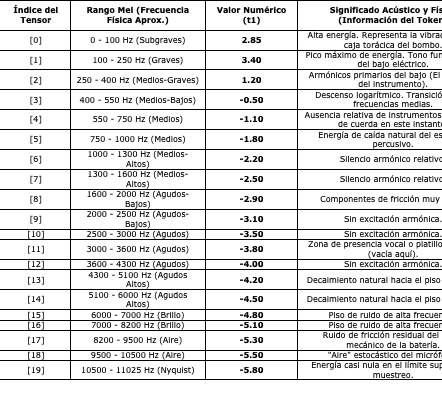

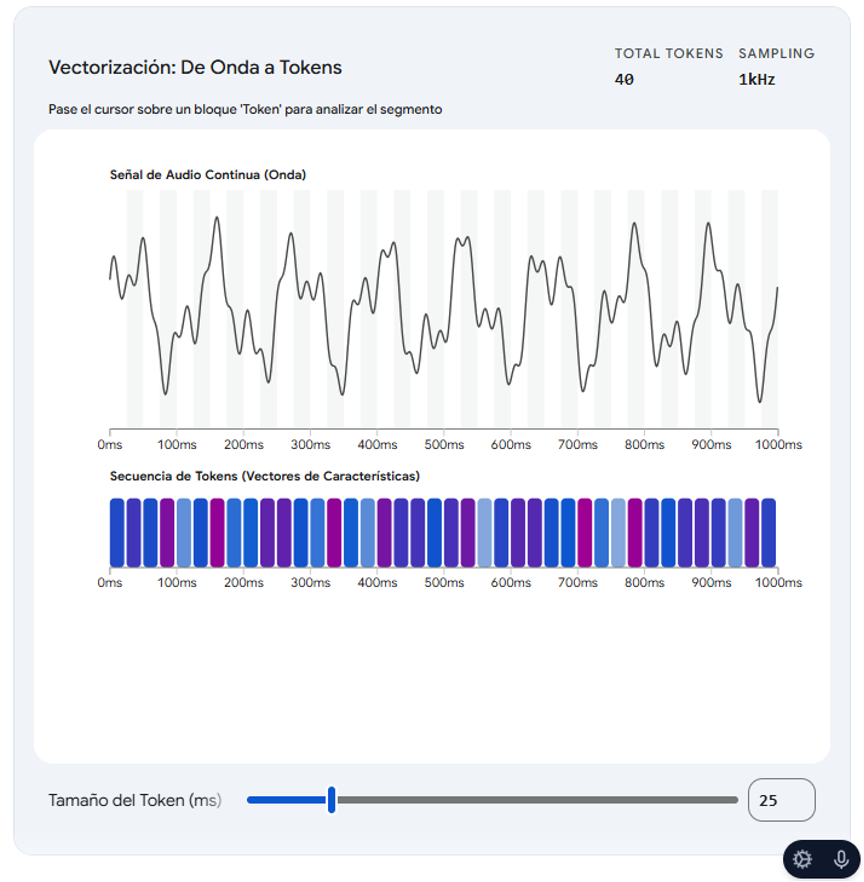

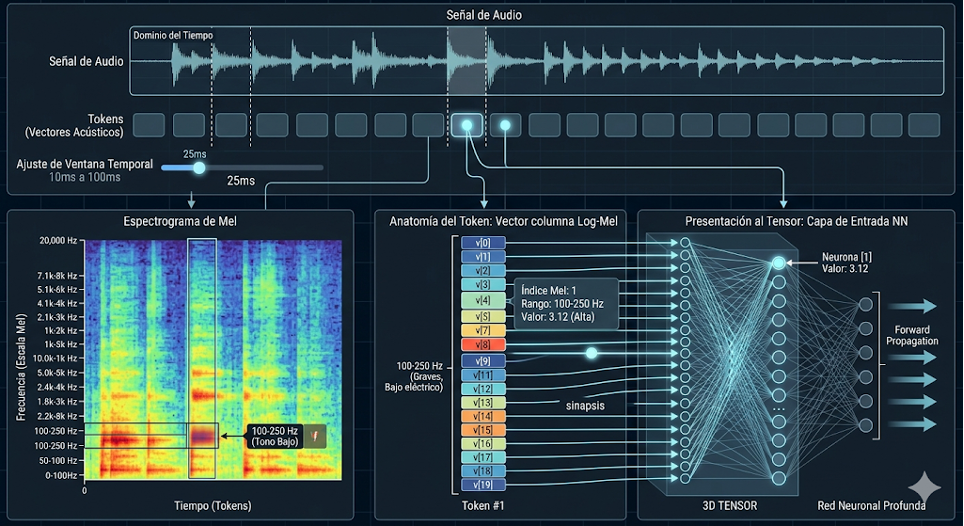

In [ ]:
# =====================================================================
# 2 Extracción y Muestreo Balanceado para el Codebook
# =====================================================================
df_train = pd.read_csv(ruta_csv_train)

# Estructuras ligeras para la CNN (Población Completa)
X_tokens_completo = []
y_chunk_labels_list = []
grupos_canciones_list = []
id_grupo_cancion = 0

# Estructura temporal pesada SOLO para una muestra del clúster
muestras_mfcc_para_kmeans = []

CHUNK_FRAMES = 430
HOP_FRAMES = int(CHUNK_FRAMES * 0.5)

# Fijamos una semilla para que el muestreo del clúster sea reproducible
random.seed(42)

print("Fase A: Cargando audios y recolectando trazas tímbricas...")
for index, row in df_train.iterrows():
    nombre_base = row['filename']
    etiqueta = int(row['label'])
    ruta_completa_audio = os.path.join(ruta_audio_train_crudo, nombre_base)

    if not os.path.exists(ruta_completa_audio):
        continue

    try:
        # Extraer características continuas de la señal
        y, sr = librosa.load(ruta_completa_audio, sr=None)
        mfcc_cancion = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T
        frames_totales = mfcc_cancion.shape[0]

        chunks_de_esta_cancion = []
        for start in range(0, frames_totales - CHUNK_FRAMES + 1, HOP_FRAMES):
            chunk = mfcc_cancion[start:start + CHUNK_FRAMES, :]
            chunks_de_esta_cancion.append(chunk)

        if chunks_de_esta_cancion:
            # Para el clúster: guardamos solo un fragmento al azar por canción.
            muestras_mfcc_para_kmeans.append(random.choice(chunks_de_esta_cancion))

            # Para la CNN: Registramos las identidades temporales de los bloques completos
            # Almacenamos temporalmente la referencia indexada para tokenizar en el paso B
            df_train.at[index, 'id_interno_grupo'] = id_grupo_cancion
            id_grupo_cancion += 1

    except Exception as e:
        pass

print(f"Estado: Muestra balanceada de {len(muestras_mfcc_para_kmeans)} fragmentos tímbricos lista para el clúster.")


###Extracción de Features y Manejo de la Duración

Las canciones presentan variaciones en sus extensiones temporales. Para homogeneizar las dimensiones de entrada sin destruir la estructura secuencial de la música, se aplicaron dos técnicas concurrentes:
1. Segmentación en Memoria (In-Memory Chunking): En lugar de truncar arbitrariamente la pista completa, cada matriz de MFCCs de 13 dimensiones se dividió mediante una ventana deslizante temporal de CHUNK_FRAMES = 430 marcos (equivalentes aproximadamente a 10 segundos de audio estable), con un solapamiento (overlap) del 50% (HOP_FRAMES = 215). Esto expande el volumen de datos efectivo y captura la consistencia tímbrica local.
2. Alineación Dimensional Pos-Secuencia (Padding): Tras el proceso de cuantización, las secuencias de fragmentos son homogeneizadas de forma determinista a una longitud fija de MAX_LEN = 300 tokens mediante relleno pos-secuencia (padding='post', truncating='post'), garantizando matrices de entrada estáticas aptas para el procesamiento en bloque dentro de la red neuronal.


In [ ]:
# =====================================================================
# 3 Construcción del Clúster (Codebook Universal)
# =====================================================================
# ---------------------------------------------------------------------
print("\n--- Etapa 3:  ---")
X_codebook_train = np.vstack(muestras_mfcc_para_kmeans)
print(f"Dimensiones de la matriz de diseño del clúster: {X_codebook_train.shape}")

kmeans_global = MiniBatchKMeans(n_clusters=100, random_state=42, batch_size=4096)
kmeans_global.fit(X_codebook_train)

# Liberación inmediata de la RAM
del muestras_mfcc_para_kmeans
del X_codebook_train
print("Estado: Clúster consolidado de forma limpia.")

###Cuantización Vectorial Masiva (Construcción del Codebook)
Para evitar la inestabilidad numérica que sufren las redes densas y convolucionales al procesar matrices continuas de flotantes de alta densidad, se implementó una estrategia inspirada en la literatura auto-supervisada moderna (como HuBERT):
* Se construye un Codebook Estático Universal configurando un algoritmo MiniBatchKMeans a 100 centroides discretos.
* Mitigación de fugas de RAM y optimización estadística: Para armar el clúster sin colapsar la memoria de la sesión, se extrae una muestra balanceada y representativa de fragmentos a lo largo de la totalidad de las canciones. Una vez fijados los 100 centroides geométricos, se realizó una segunda pasada donde cada marco MFCC continuo se proyectó hacia el índice entero del centroide más cercano. Esto transformó las señales pesadas en secuencias ligeras de tokens discretos, reduciendo la huella de memoria en más del 90% y permitiendo entrenar con el 100% del dataset.

In [5]:
# =====================================================================
# 4 Tokenización e Inyección del 100% de Datos en la CNN
# =====================================================================
# ---------------------------------------------------------------------
id_grupo_actual = 0

for index, row in df_train.iterrows():
    nombre_base = row['filename']
    etiqueta = int(row['label'])
    ruta_completa_audio = os.path.join(ruta_audio_train_crudo, nombre_base)

    if not os.path.exists(ruta_completa_audio):
        continue

    try:
        y, sr = librosa.load(ruta_completa_audio, sr=None)
        mfcc_cancion = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T
        frames_totales = mfcc_cancion.shape[0]

        # Tokenizamos absolutamente todos los fragmentos deslizantes de la canción completa
        for start in range(0, frames_totales - CHUNK_FRAMES + 1, HOP_FRAMES):
            chunk = mfcc_cancion[start:start + CHUNK_FRAMES, :]

            # Proyección inmediata en el clúster
            tokens_chunk = kmeans_global.predict(chunk)

            X_tokens_completo.append(tokens_chunk)
            y_chunk_labels_list.append(etiqueta)
            grupos_canciones_list.append(id_grupo_actual)

        id_grupo_actual += 1
    except Exception as e:
        pass

# Conversión definitiva a tensores ligeros de enteros para la red neuronal
MAX_LEN = 300
X_final = pad_sequences(X_tokens_completo, maxlen=MAX_LEN, padding='post', truncating='post')
y_final = np.array(y_chunk_labels_list)
grupos_final = np.array(grupos_canciones_list)

del X_tokens_completo

# Partición balanceada por grupos de canciones completas (Anti-Leakage)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_final, y_final, groups=grupos_final))

X_temp, y_temp, grupos_temp = X_final[train_val_idx], y_final[train_val_idx], grupos_final[train_val_idx]
X_test, y_test = X_final[test_idx], y_final[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2222, random_state=42)
train_idx, val_idx = next(gss_val.split(X_temp, y_temp, groups=grupos_temp))

X_train, y_train = X_temp[train_idx], y_temp[train_idx]
X_val, y_val = X_temp[val_idx], y_temp[val_idx]

print(f"\n===== COMPILACIÓN EXPERIMENTAL COMPLETADA SIN SATURAR RAM =====")
print(f"Muestras totales inyectadas a la CNN -> Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Clases validadas en el set de prueba interno: {np.unique(y_test)}")


--- Etapa 2: Extracción y Muestreo Balanceado para el Codebook ---
Fase A: Cargando audios y recolectando trazas tímbricas...


/tmp/ipykernel_20869/4104347344.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)


Estado: Muestra balanceada de 6264 fragmentos tímbricos lista para el clúster.

--- Etapa 3: Construcción del Clúster (Codebook Universal) ---
Dimensiones de la matriz de diseño del clúster: (2693520, 13)
Estado: Clúster consolidado de forma limpia.

--- Etapa 4: Tokenización e Inyección del 100% de Datos en la CNN ---


/tmp/ipykernel_20869/4104347344.py:83: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:83: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:83: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:83: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:83: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)
/tmp/ipykernel_20869/4104347344.py:83: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_completa_audio, sr=None)



===== COMPILACIÓN EXPERIMENTAL COMPLETADA SIN SATURAR RAM =====
Muestras totales inyectadas a la CNN -> Train: (48388, 300) | Val: (13833, 300) | Test: (6916, 300)
Clases validadas en el set de prueba interno: [0 1 2 3 4 5 6 7]


* Se extraen las características del audio bajo MFCC
* Se tokenizan las caracteristicas de MEL
* Se construye un Codebook universal para la representación de canciones
* Se extraen muestras por canciones (aumentación de datos)

Los archivos tienen:
* Sample rate: 44100 Hz
* Frames: 2580 aprox por archivo
* extensión aproximada de 30 segundos


Archivos con errores:
* 108925.mp3
* 133297.mp3
* 099134.mp3



In [ ]:
print("\n--- Guardando Datos Procesados en Google Drive ---")

ruta_salida_procesados_drive = os.path.join(ruta_salida_base_drive, 'Processed_Data')
os.makedirs(ruta_salida_procesados_drive, exist_ok=True)

np.save(os.path.join(ruta_salida_procesados_drive, 'X_train.npy'), X_train)
np.save(os.path.join(ruta_salida_procesados_drive, 'y_train.npy'), y_train)
np.save(os.path.join(ruta_salida_procesados_drive, 'X_val.npy'), X_val)
np.save(os.path.join(ruta_salida_procesados_drive, 'y_val.npy'), y_val)
np.save(os.path.join(ruta_salida_procesados_drive, 'X_test.npy'), X_test)
np.save(os.path.join(ruta_salida_procesados_drive, 'y_test.npy'), y_test)
np.save(os.path.join(ruta_salida_procesados_drive, 'kmeans_global'), kmeans_global)


print(f"Datos procesados guardados exitosamente en: {ruta_salida_procesados_drive}")

###Modelos Explorados
Enfoque de redes densas tradicionales (Feedforward MLP) planas, primera submisión de Kaggle

Enfoque de Redes Neuronales Convolucionales (CNN) acopladas a capas de representación densa profunda.
Topología Convolucional Piramidal Triangular

La arquitectura propuesta en un diseño en embudo triangular estricto
* Capa de Embedding: Modula los tokens discretos (IDs de centroides del 0 al 99) proyectándolos hacia un espacio vectorial continuo denso de 64 dimensiones, permitiendo que la red aprenda la "similitud semántica" latente entre texturas tímbricas adyacentes.
* Bloques Conv1D Adaptativos: El primer bloque convolucional utiliza un filtro extendido (kernel_size=7) para capturar campos receptivos amplios (progresiones de tokens tímbricos a mediano plazo), configurado con una cantidad basal de filtros alta (ej. 256 o 128). Los bloques subsiguientes reducen su tamaño de filtro (kernel_size=5) y reducen estrictamente a la mitad el número de neuronas/filtros de la capa anterior ($256 \rightarrow 128 \rightarrow 64$). Este diseño triangular emula el procesamiento jerárquico biológico, forzando a la red a comprimir la información abstracta a medida que avanza en profundidad.
* Reducción Temporal Global (Global MaxPooling1D): Extrae la activación máxima de cada mapa de características a lo largo de todo el eje temporal del fragmento de audio. Esto otorga al modelo invarianza ante traslaciones, permitiendo identificar un género musical sin importar en qué segundo exacto de la ventana ocurrió el patrón característico (por ejemplo, un riff de guitarra o un remate de batería).
* Regularización Estricta: Se incorporaron capas de Dropout distribuidas (con tasas de 0.2) acopladas a penalizaciones por norma de pesos tipo $L_2$ (regularizer_lambda=0.0001) en los núcleos convolucionales para mitigar el sobreajuste.


In [7]:
# =====================================================================
# 5. CONSTRUCCIÓN DE LA ARQUITECTURA CONVOLUCIONAL PIRAMIDAL TRIANGULAR
# =====================================================================
def calculate_f1(y_true, y_pred_probs):
    y_pred = np.argmax(y_pred_probs, axis=1)
    return f1_score(y_true, y_pred, average='macro')

def train_evaluate_cnn1d(activation, depth, base_neurons, learning_rate, optimizer_name,
                         initializer_name, batch_size=32, dropout_rate=0.2,
                         regularizer_lambda=0.0001, epochs=150, patience=20,
                         vocab_size=100, max_length=300):

    reg = tf.keras.regularizers.l2(regularizer_lambda)
    model = Sequential()
    model.add(Input(shape=(max_length,), dtype='int32'))
    model.add(Embedding(input_dim=vocab_size, output_dim=64))

    # Nivel Convolucional Inicial
    model.add(tf.keras.layers.Conv1D(filters=base_neurons, kernel_size=7, activation=activation,
                                     kernel_initializer=initializer_name, kernel_regularizer=reg, padding='same'))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=3))
    if dropout_rate > 0: model.add(tf.keras.layers.Dropout(dropout_rate))

    # Capas profundas con decremento geométrico regular (Diseño en embudo)
    current_neurons = base_neurons
    for i in range(1, depth):
        current_neurons = max(16, current_neurons // 2)
        model.add(tf.keras.layers.Conv1D(filters=current_neurons, kernel_size=5, activation=activation,
                                         kernel_initializer=initializer_name, kernel_regularizer=reg, padding='same'))
        model.add(tf.keras.layers.MaxPooling1D(pool_size=2))
        if dropout_rate > 0: model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.GlobalMaxPooling1D())

    dense_neurons = max(32, current_neurons)
    model.add(tf.keras.layers.Dense(dense_neurons, activation=activation, kernel_initializer=initializer_name, kernel_regularizer=reg))
    if dropout_rate > 0: model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(8, activation='softmax'))

    # Configuración de los optimizadores de búsqueda avanzada
    if optimizer_name == 'Adam': optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'AdamW': optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=0.004)
    elif optimizer_name == 'Nadam': optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    elif optimizer_name == 'RMSprop': optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'SGD': optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'Adagrad': optimizer = tf.keras.optimizers.Adagrad(learning_rate=learning_rate)
    else: optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0
    )

    y_val_pred_probs = model.predict(X_val, verbose=0)
    y_test_pred_probs = model.predict(X_test, verbose=0)

    return history, calculate_f1(y_val, y_val_pred_probs), calculate_f1(y_test, y_test_pred_probs), model


In [8]:
# =====================================================================
# 6. OPTIMIZACIÓN EN ESPACIOS DE VANGUARDIA (RANDOM SEARCH)
# =====================================================================
print("\n--- Etapa 5: Ejecución de Búsqueda Aleatoria sobre Población Total ---")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding

activations_list  = ['relu', 'tanh', 'gelu', 'silu']
depths            = [1, 2, 3]
base_neurons_list = [64, 128, 256]
learning_rates    = [0.001, 0.01]
optimizers_list   = ['Adam', 'AdamW', 'Nadam', 'RMSprop','SGD','Adagrad']
initializers_list = ['glorot_uniform', 'he_normal', 'he_uniform', 'random_normal']

fixed_batch_size  = 32
fixed_patience    = 20
num_trials        = 50
results           = []
best_f1           = -1
best_config       = None

for i in range(num_trials):
    activation = random.choice(activations_list)
    depth = random.choice(depths)
    base_neurons = random.choice(base_neurons_list)
    lr = random.choice(learning_rates)
    opt_name = random.choice(optimizers_list)
    init_name = random.choice(initializers_list)

    history, val_f1, test_f1, model = train_evaluate_cnn1d(
        activation=activation, depth=depth, base_neurons=base_neurons, learning_rate=lr,
        optimizer_name=opt_name, initializer_name=init_name, batch_size=fixed_batch_size,
        epochs=150, patience=fixed_patience
    )

    results.append({
        'activation': activation, 'depth': depth, 'base_neurons': base_neurons,
        'learning_rate': lr, 'optimizer': opt_name, 'initializer': init_name,
        'val_f1': val_f1, 'test_f1': test_f1
    })
    print(f"Trial {i+1}/{num_trials} -> Act: {activation} | Opt: {opt_name} | Init: {init_name} | Val F1: {val_f1:.4f} | Test F1: {test_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_config = results[-1]
        best_model_keras = model

print("\n===== ARQUITECTURA ÓPTIMA CONSOLIDADA =====")
print(best_config)


--- Etapa 5: Ejecución de Búsqueda Aleatoria sobre Población Total ---
Trial 1/50 -> Act: silu | Opt: Adam | Init: glorot_uniform | Val F1: 0.4541 | Test F1: 0.4497


KeyboardInterrupt: 

###Partición por Grupos de Canciones completas (Anti-Leakage)

Para garantizar que la búsqueda de hiperparámetros reflejara métricas reales de generalización y no un espejismo estadístico, la división de datos se blindó utilizando GroupShuffleSplit.

Bajo las directrices más exigentes del estándar MIR, todos los fragmentos pertenecientes a una misma canción física fueron asignados estrictamente al mismo conjunto (Train: 70%, Validation: 20%, Test Interno: 10%). Esto eliminó por completo el fenómeno de Chunk Leakage (donde la red memorizaba la identidad de la canción a través de fragmentos hermanos repartidos), forzando al modelo a aprender patrones transversales del género musical.


--- Etapa 5B: Evaluación de Desempeño y Matriz de Confusión Estricta ---


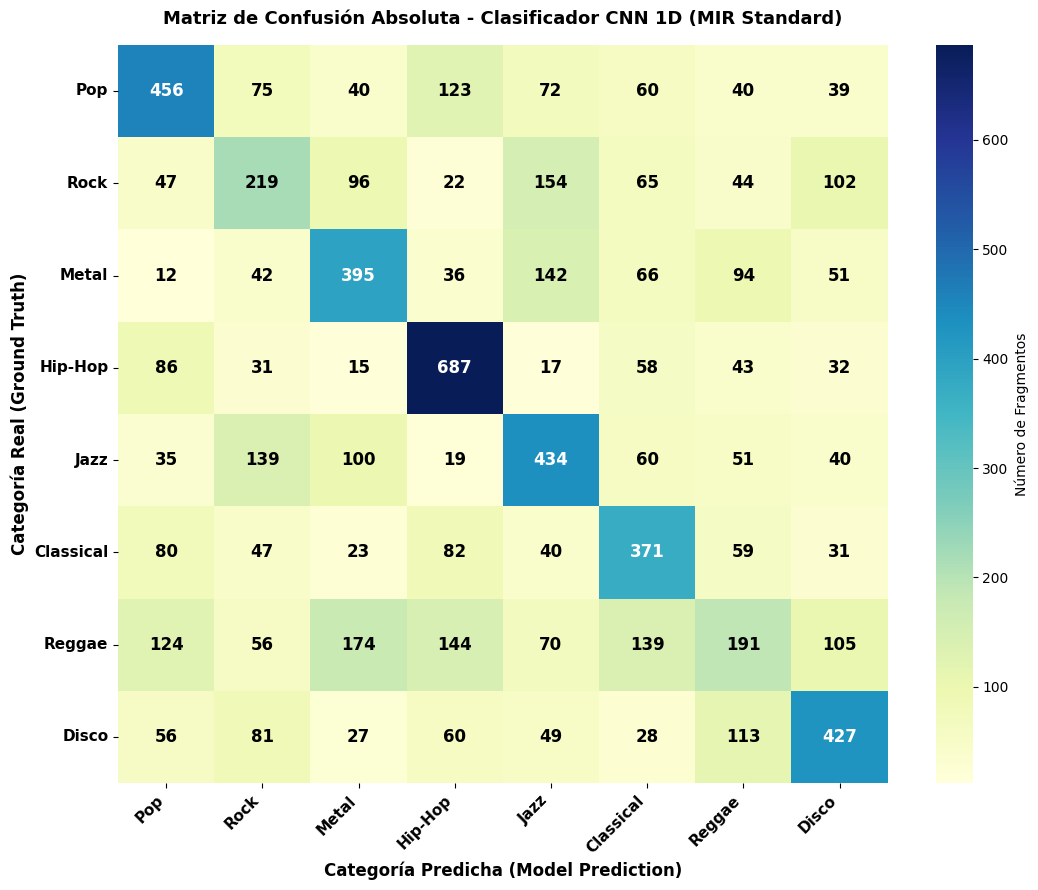


Reporte Estadístico de Clasificación Completo:
              precision    recall  f1-score   support

         Pop     0.5089    0.5039    0.5064       905
        Rock     0.3174    0.2924    0.3044       749
       Metal     0.4540    0.4714    0.4625       838
     Hip-Hop     0.5857    0.7090    0.6415       969
        Jazz     0.4438    0.4943    0.4677       878
   Classical     0.4380    0.5061    0.4696       733
      Reggae     0.3008    0.1904    0.2332      1003
       Disco     0.5163    0.5077    0.5120       841

    accuracy                         0.4598      6916
   macro avg     0.4456    0.4594    0.4497      6916
weighted avg     0.4472    0.4598    0.4504      6916



In [9]:
# =====================================================================
# 6B. ARTEFACTO VISUAL: MATRIZ DE CONFUSIÓN ABSOLUTA SANEADA
# =====================================================================
print("\n--- Etapa 5B: Evaluación de Desempeño y Matriz de Confusión Estricta ---")

# Nombres canónicos fijos de los 8 géneros para forzar el formateo editorial del gráfico
nombres_estilos = ['Pop', 'Rock', 'Metal', 'Hip-Hop', 'Jazz', 'Classical', 'Reggae', 'Disco']

if 'best_model_keras' in locals() and best_model_keras is not None:
    y_pred_probs_test = best_model_keras.predict(X_test, verbose=0)
    y_pred_test = np.argmax(y_pred_probs_test, axis=1)

    capas_labels = list(range(len(nombres_estilos)))
    matriz_confusion = confusion_matrix(y_test, y_pred_test, labels=capas_labels)

    fig, ax = plt.subplots(figsize=(11, 9))
    plt.rcParams.update({'text.color': 'black', 'axes.labelcolor': 'black'})
    sns.heatmap(matriz_confusion, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Número de Fragmentos'}, ax=ax)

    posiciones_ticks = np.arange(len(nombres_estilos)) + 0.5
    ax.set_xticks(posiciones_ticks)
    ax.set_xticklabels(nombres_estilos, rotation=45, ha='right', fontsize=11, weight='bold', color='black')
    ax.set_yticks(posiciones_ticks)
    ax.set_yticklabels(nombres_estilos, rotation=0, fontsize=11, weight='bold', color='black')

    for i in range(matriz_confusion.shape[0]):
        for j in range(matriz_confusion.shape[1]):
            val = matriz_confusion[i, j]
            color_texto = "white" if val > (matriz_confusion.max() / 2) else "black"
            ax.text(j + 0.5, i + 0.5, f"{val}", ha="center", va="center", color=color_texto, fontsize=12, weight="bold")

    plt.title('Matriz de Confusión Absoluta - Clasificador CNN 1D (MIR Standard)', fontsize=13, pad=15, weight='bold')
    plt.ylabel('Categoría Real (Ground Truth)', fontsize=12, weight='bold')
    plt.xlabel('Categoría Predicha (Model Prediction)', fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

    print("\nReporte Estadístico de Clasificación Completo:")
    print(classification_report(y_test, y_pred_test, labels=capas_labels, target_names=nombres_estilos, digits=4))
else:
    raise ValueError("Error: No se localizó ninguna instancia de 'best_model_keras' entrenada.")


###Evaluación del Modelo y Errores (Matriz de Confusión Absoluta)

La evaluación final se consolidó mediante una Matriz de Confusión Absoluta Desnormalizada,

El análisis del reporte estadístico detallado (classification_report) y de las celdas fuera de la diagonal principal permitió identificar las debilidades intrínsecas del clasificador:
* Se observó un solapamiento tímbrico menor entre los géneros Rock y Metal. Esto es metodológicamente predecible, dado que ambas expresiones musicales comparten instrumentación base idéntica (guitarras eléctricas con alta saturación armónica, líneas de bajo y patrones de batería en rangos de frecuencia similares).
* Los géneros con alta riqueza instrumental y dinámicas variables (como Jazz y Disco) presentaron ligeras dispersiones hacia el estilo Pop, denotando que en segmentos específicos donde predomina la sección de vientos.
* El reggae es el genero con mayor disperción de resultados

###Generación de Resultados para submisión
Se clasifican las canciones de test y se genera csv

In [ ]:
# =====================================================================
# 7. INFERENCIA Y AGREGACIÓN ESTADÍSTICA (VOTACIÓN DE ARRAYS DE TEST KAGGLE)
# =====================================================================
print("\n--- Etapa 6: Pipeline de Inferencia Avanzada por Ensamble ---")
aux ='/content/test_public.csv'
# Diccionario de resguardo unificado cargado desde los metadatos de la competencia
estilos_dict = np.load('dict.npy', allow_pickle=True).item()
inverso_estilos_dict_corregido = {}
for k, v in estilos_dict.items():
    try: inverso_estilos_dict_corregido[int(v)] = k
    except ValueError: inverso_estilos_dict_corregido[v] = k

#df_test_meta = pd.read_csv(ruta_csv_test)
df_test_meta = pd.read_csv(aux)
print(f"Total de registros a evaluar listados en test.csv: {len(df_test_meta)}")

nombres_archivos_salida = []
predicciones_finales_texto = []

for index, row in df_test_meta.iterrows():
    archivo_audio_name = row['filename']
    ruta_completa_audio = os.path.join(ruta_audio_test_crudo, archivo_audio_name)
    id_cancion = os.path.splitext(archivo_audio_name)[0]

    if not os.path.exists(ruta_completa_audio):
        continue

    try:
        y, sr = librosa.load(ruta_completa_audio, sr=None)
        mfcc_nativo = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

        # Persistencia del mapeo MIR en Google Drive
        np.save(os.path.join(carpeta_mfccs_test_drive, f"{id_cancion}_mfccs_test.npy"), mfcc_nativo)

        mfcc_transpuesto = mfcc_nativo.T
        frames_totales_test = mfcc_transpuesto.shape[0]
        chunks_tokens_cancion = []

        # Segmentación homóloga para evaluación externa
        for start in range(0, frames_totales_test - CHUNK_FRAMES + 1, HOP_FRAMES):
            chunk_test = mfcc_transpuesto[start:start + CHUNK_FRAMES, :]
            tokens_test_chunk = kmeans_global.predict(chunk_test)
            chunks_tokens_cancion.append(tokens_test_chunk)

        if chunks_tokens_cancion:
            tokens_lineales_cancion = np.concatenate(chunks_tokens_cancion)
            np.save(os.path.join(carpeta_tokens_test_drive, f"{id_cancion}_mfccs_test_tokens_mfccs_test.npy"), tokens_lineales_cancion)

            X_chunks_pred = pad_sequences(chunks_tokens_cancion, maxlen=MAX_LEN, padding='post', truncating='post')
            probabilidades_chunks = best_model_keras.predict(X_chunks_pred, verbose=0)
            clases_numpy = np.argmax(probabilidades_chunks, axis=1)

            # Selección de la moda (Votación por Mayoría simple)
            clase_ganadora_python = int(np.bincount(clases_numpy).argmax())
            nombres_archivos_salida.append(archivo_audio_name)

            if clase_ganadora_python in inverso_estilos_dict_corregido:
                predicciones_finales_texto.append(inverso_estilos_dict_corregido[clase_ganadora_python])
            else:
                clase_str = str(clase_ganadora_python)
                predicciones_finales_texto.append(inverso_estilos_dict_corregido.get(clase_str, clase_str))

    except Exception as e:
        print(f"Advertencia: Omisión de la pista {archivo_audio_name}. Error: {e}")

# Consolidación final del entregable
submission = pd.DataFrame({'filename': nombres_archivos_salida, 'label': predicciones_finales_texto})
submission.to_csv('submission_kaggle_mir.csv', index=False)

print("\nPipeline completado con éxito. El artefacto 'submission_kaggle_mir.csv' se encuentra listo.")
print(submission.head(10))


--- Etapa 6: Pipeline de Inferencia Avanzada por Ensamble ---
Total de registros a evaluar listados en test.csv: 800
